# Trabajo Final - Pipeline de preprocesamiento y baseline de clasificación

Este notebook construye un flujo reproducible para preparar el dataset inicial, eliminar columnas previamente identificadas, crear variables derivadas, transformar variables categóricas y entrenar un modelo baseline de **Regresión Logística One-vs-One**.

El diseño busca evitar fuga de información (*data leakage*) porque las transformaciones de imputación, codificación y escalamiento se aprenden únicamente sobre `X_train` dentro de un `Pipeline` de `scikit-learn`.

## 1. Configuración inicial

Se definen rutas, semilla de reproducibilidad y librerías necesarias. Las rutas están configuradas para Google Colab y Google Drive.

In [1]:
# ============================================================
# 1. Configuración inicial
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

SEED = 42
np.random.seed(SEED)

BASE_DIR = "/content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output"

DATASET_PATH = os.path.join(BASE_DIR, "DataSetInicial.csv")
COLUMNAS_ELIMINAR_PATH = os.path.join(BASE_DIR, "Columas a Eliminar.csv")

TARGET_COL = "target"

# En el dataset completo, déjalo en False. Para pruebas rápidas, cambia a True.
MODO_DESARROLLO = False
N_FILAS_DESARROLLO = 100_000

print("Ruta dataset:", DATASET_PATH)
print("Ruta columnas a eliminar:", COLUMNAS_ELIMINAR_PATH)

Ruta dataset: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/DataSetInicial.csv
Ruta columnas a eliminar: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/Columas a Eliminar.csv


## 2. Montar Google Drive

Esta celda monta Google Drive en Colab. Si ya está montado, no hay problema en ejecutarla nuevamente.

In [2]:
# ============================================================
# 2. Montar Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 3. Carga del dataset y archivo de columnas a eliminar

Se carga el dataset inicial y el archivo `Columas a Eliminar.csv`. También se normalizan los nombres de columnas para evitar problemas por espacios, mayúsculas o caracteres invisibles.

In [4]:
# ============================================================
# 3. Carga del dataset y columnas a eliminar
# ============================================================

def limpiar_nombre_columnas(df):
    """
    Normaliza nombres de columnas:
    - elimina espacios extremos,
    - elimina caracteres BOM,
    - convierte a minúscula.
    """
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
        .str.lower()
    )
    return df


if MODO_DESARROLLO:
    df = pd.read_csv(
        DATASET_PATH,
        encoding="utf-8-sig",
        low_memory=False,
        nrows=N_FILAS_DESARROLLO
    )
else:
    df = pd.read_csv(
        DATASET_PATH,
        encoding="utf-8-sig",
        low_memory=False
    )

df = limpiar_nombre_columnas(df)

columnas_eliminar_df = pd.read_csv(
    COLUMNAS_ELIMINAR_PATH,
    encoding="utf-8-sig",
    low_memory=False
)

columnas_eliminar_df = limpiar_nombre_columnas(columnas_eliminar_df)

print("Shape dataset inicial:", df.shape)
display(df.head())

print("\nArchivo de columnas a eliminar:")
display(columnas_eliminar_df)

Shape dataset inicial: (566241, 33)


,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_depto_ubicacion,cole_genero,cole_jornada,...,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,target
0,20224,TI,SB11202240536228,URBANO,N,A,TÉCNICO/ACADÉMICO,CAQUETA,MIXTO,UNICA,...,Cuatro,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,No,Si,Nivel 2: Mínimo
1,20224,TI,SB11202240549969,URBANO,N,A,TÉCNICO/ACADÉMICO,QUINDIO,MIXTO,MAÑANA,...,Dos,Educación profesional completa,No Aplica,Estrato 2,3 a 4,No,No,Si,Si,Nivel 2: Mínimo
2,20211,TI,SB11202110001547,RURAL,S,B,ACADÉMICO,CUNDINAMARCA,MIXTO,COMPLETA,...,Tres,Educación profesional completa,Postgrado,Estrato 4,3 a 4,Si,Si,Si,Si,Nivel 3: Satisfactorio
3,20211,CR,SB11202110021004,URBANO,NaN,A,ACADÉMICO,CUNDINAMARCA,MIXTO,MAÑANA,...,Tres,Educación profesional completa,Educación profesional completa,Estrato 5,1 a 2,Si,Si,Si,Si,Nivel 3: Satisfactorio
4,20224,TI,SB11202240101947,RURAL,NaN,A,NO APLICA,ANTIOQUIA,MIXTO,COMPLETA,...,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,3 a 4,No,No,No,No,Nivel 3: Satisfactorio



Archivo de columnas a eliminar:


,columna_a_eliminar
0,cole_area_ubicacion
1,estu_mcpio_presentacion
2,estu_nacionalidad
3,estu_depto_presentacion
4,fami_tieneautomovil
5,cole_depto_ubicacion
6,estu_depto_reside
7,fami_tienelavadora
8,estu_mcpio_reside
9,estu_estudiante


## 4. Validaciones iniciales

Antes del procesamiento se valida que exista la variable objetivo y que el archivo de columnas a eliminar tenga una estructura interpretable.

In [5]:
# ============================================================
# 4. Validaciones iniciales
# ============================================================

if TARGET_COL not in df.columns:
    raise ValueError(f"No existe la variable objetivo '{TARGET_COL}' en el dataset.")

if columnas_eliminar_df.shape[1] == 1:
    col_lista_eliminar = columnas_eliminar_df.columns[0]
else:
    col_lista_eliminar = "columna_a_eliminar"
    if col_lista_eliminar not in columnas_eliminar_df.columns:
        raise ValueError(
            "El archivo de columnas a eliminar debe tener una columna llamada "
            "'columna_a_eliminar' o una única columna con el listado."
        )

columnas_a_eliminar = (
    columnas_eliminar_df[col_lista_eliminar]
    .dropna()
    .astype(str)
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
    .str.lower()
    .tolist()
)

columnas_a_eliminar = sorted(set(columnas_a_eliminar + ["periodo"]))

print("Variable objetivo:", TARGET_COL)
print("Cantidad de columnas solicitadas para eliminar:", len(columnas_a_eliminar))
print(columnas_a_eliminar)

Variable objetivo: target
Cantidad de columnas solicitadas para eliminar: 15
['cole_area_ubicacion', 'cole_depto_ubicacion', 'cole_sede_principal', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_mcpio_presentacion', 'estu_mcpio_reside', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_tieneautomovil', 'fami_tienelavadora', 'periodo']


## 5. Eliminación de columnas y control de duplicados

Se eliminan las columnas indicadas en el archivo externo y la columna `periodo`.

Como buena práctica, se revisan duplicados por `estu_consecutivo`, ya que esta variable identifica al estudiante. Si existen duplicados, se conserva el primer registro. Después de usarla para depuración, esta columna se excluye del conjunto de predictores para evitar que actúe como identificador de alta cardinalidad.

In [6]:
# ============================================================
# 5. Eliminación de columnas y duplicados por estu_consecutivo
# ============================================================

columnas_existentes_a_eliminar = [col for col in columnas_a_eliminar if col in df.columns]
columnas_no_encontradas = [col for col in columnas_a_eliminar if col not in df.columns]

df_model = df.drop(columns=columnas_existentes_a_eliminar).copy()

print("Columnas eliminadas efectivamente:", len(columnas_existentes_a_eliminar))
print(columnas_existentes_a_eliminar)

if columnas_no_encontradas:
    print("\nColumnas solicitadas pero no encontradas en el dataset:")
    print(columnas_no_encontradas)

if "estu_consecutivo" in df_model.columns:
    registros_antes = len(df_model)
    duplicados = df_model.duplicated(subset=["estu_consecutivo"], keep=False).sum()

    print(f"\nRegistros involucrados en duplicados por estu_consecutivo: {duplicados:,}")

    df_model = (
        df_model
        .drop_duplicates(subset=["estu_consecutivo"], keep="first")
        .reset_index(drop=True)
    )

    registros_despues = len(df_model)
    print(f"Registros antes: {registros_antes:,}")
    print(f"Registros después de eliminar duplicados: {registros_despues:,}")
    print(f"Registros eliminados: {registros_antes - registros_despues:,}")

print("\nShape después de eliminación de columnas y duplicados:", df_model.shape)
display(df_model.head())

Columnas eliminadas efectivamente: 15
['cole_area_ubicacion', 'cole_depto_ubicacion', 'cole_sede_principal', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_mcpio_presentacion', 'estu_mcpio_reside', 'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad', 'fami_tieneautomovil', 'fami_tienelavadora', 'periodo']

Registros involucrados en duplicados por estu_consecutivo: 0
Registros antes: 566,241
Registros después de eliminar duplicados: 566,241
Registros eliminados: 0

Shape después de eliminación de columnas y duplicados: (566241, 18)


,estu_tipodocumento,estu_consecutivo,cole_bilingue,cole_calendario,cole_caracter,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_genero,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tienecomputador,fami_tieneinternet,target
0,TI,SB11202240536228,N,A,TÉCNICO/ACADÉMICO,MIXTO,UNICA,EL DONCELLO,OFICIAL,F,Cuatro,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,Nivel 2: Mínimo
1,TI,SB11202240549969,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,ARMENIA,OFICIAL,F,Dos,Educación profesional completa,No Aplica,Estrato 2,3 a 4,No,Si,Nivel 2: Mínimo
2,TI,SB11202110001547,S,B,ACADÉMICO,MIXTO,COMPLETA,SOPÓ,NO OFICIAL,M,Tres,Educación profesional completa,Postgrado,Estrato 4,3 a 4,Si,Si,Nivel 3: Satisfactorio
3,CR,SB11202110021004,NaN,A,ACADÉMICO,MIXTO,MAÑANA,TENJO,NO OFICIAL,M,Tres,Educación profesional completa,Educación profesional completa,Estrato 5,1 a 2,Si,Si,Nivel 3: Satisfactorio
4,TI,SB11202240101947,NaN,A,NO APLICA,MIXTO,COMPLETA,ANDES,OFICIAL,M,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,3 a 4,No,No,Nivel 3: Satisfactorio


## 6. Separación de variables predictoras y variable objetivo

Se separa `X` y `y`. La columna `estu_consecutivo` se elimina de `X` porque es un identificador y no debe usarse para entrenar el modelo.

In [7]:
# ============================================================
# 6. Separación X/y
# ============================================================

df_model = df_model.dropna(subset=[TARGET_COL]).reset_index(drop=True)

id_cols_no_modelar = ["estu_consecutivo"]
id_cols_no_modelar = [col for col in id_cols_no_modelar if col in df_model.columns]

X = df_model.drop(columns=[TARGET_COL] + id_cols_no_modelar).copy()
y = df_model[TARGET_COL].copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nDistribución del target:")
display(y.value_counts(dropna=False).to_frame("frecuencia"))
display((y.value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("porcentaje"))

Shape X: (566241, 16)
Shape y: (566241,)

Distribución del target:


,frecuencia
target,
Nivel 2: Mínimo,268741
Nivel 3: Satisfactorio,170346
Nivel 1: Insuficiente,104523
Nivel 4: Avanzado,22631


,porcentaje
target,
Nivel 2: Mínimo,47.46
Nivel 3: Satisfactorio,30.08
Nivel 1: Insuficiente,18.46
Nivel 4: Avanzado,4.00


## 7. División entrenamiento/prueba

Se usa `train_test_split` con estratificación para conservar la distribución de clases del target en entrenamiento y prueba.

In [8]:
# ============================================================
# 7. Train/test split
# ============================================================

min_clase = y.value_counts().min()
stratify_y = y if min_clase >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=stratify_y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribución y_train:")
display((y_train.value_counts(normalize=True) * 100).round(2).to_frame("porcentaje_train"))

print("\nDistribución y_test:")
display((y_test.value_counts(normalize=True) * 100).round(2).to_frame("porcentaje_test"))

X_train: (452992, 16)
X_test: (113249, 16)
y_train: (452992,)
y_test: (113249,)

Distribución y_train:


,porcentaje_train
target,
Nivel 2: Mínimo,47.46
Nivel 3: Satisfactorio,30.08
Nivel 1: Insuficiente,18.46
Nivel 4: Avanzado,4.00



Distribución y_test:


,porcentaje_test
target,
Nivel 2: Mínimo,47.46
Nivel 3: Satisfactorio,30.08
Nivel 1: Insuficiente,18.46
Nivel 4: Avanzado,4.00


## 8. Transformadores personalizados

Se crean dos transformadores personalizados:

1. `CrearMayorEdad`: crea la variable `Mayor edad` desde `estu_tipodocumento` y elimina `estu_tipodocumento`.
2. `AgruparCategorias`: agrupa categorías de educación del padre, educación de la madre y municipio de ubicación del colegio.

Estas transformaciones quedan dentro del pipeline para garantizar reproducibilidad.

In [9]:
# ============================================================
# 8. Transformadores personalizados
# ============================================================

class CrearMayorEdad(BaseEstimator, TransformerMixin):
    """
    Crea la columna 'Mayor edad' a partir de 'estu_tipodocumento':
    - CC -> mayor de edad
    - TI -> Menor de edad
    - Otro valor -> No definido
    Luego elimina 'estu_tipodocumento'.
    """

    def __init__(self, columna_documento="estu_tipodocumento", nueva_columna="Mayor edad"):
        self.columna_documento = columna_documento
        self.nueva_columna = nueva_columna

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if self.columna_documento in X.columns:
            doc = (
                X[self.columna_documento]
                .astype("object")
                .fillna("NO DEFINIDO")
                .astype(str)
                .str.strip()
                .str.upper()
            )

            X[self.nueva_columna] = np.select(
                [doc.eq("CC"), doc.eq("TI")],
                ["mayor de edad", "Menor de edad"],
                default="No definido"
            )

            X = X.drop(columns=[self.columna_documento])

        return X


class AgruparCategorias(BaseEstimator, TransformerMixin):
    """
    Agrupa categorías específicas según reglas de negocio.
    """

    def __init__(self):
        self.mapa_educacion = {
            "Secundaria (Bachillerato) completa": "Secundaria",
            "Primaria incompleta": "Ninguna",
            "Secundaria (Bachillerato) incompleta": "Primaria",
            "Educación profesional completa": "Profesional",
            "Primaria completa": "Primaria",
            "No sabe": "Ninguna",
            "Técnica o tecnológica completa": "Tecnico",
            "Ninguno": "Ninguna",
            "Postgrado": "Postgrado",
            "Técnica o tecnológica incompleta": "Secundaria",
            "Educación profesional incompleta": "Secundaria",
            "No Aplica": "Ninguna"
        }

        self.mapa_municipio = {
            "BOGOTÁ D.C.": "Principal",
            "MEDELLÍN": "Principal",
            "CALI": "Principal",
            "BARRANQUILLA": "Intermedia",
            "CARTAGENA DE INDIAS": "Intermedia",
            "CÚCUTA": "Intermedia",
            "SOACHA": "Intermedia",
            "SOLEDAD": "Pequeña",
            "IBAGUÉ": "Pequeña",
            "SANTA MARTA": "Pequeña",
            "BUCARAMANGA": "Pequeña",
            "VILLAVICENCIO": "Pequeña"
        }

    def fit(self, X, y=None):
        return self

    @staticmethod
    def _mapear_serie(serie, mapa, default_original=True, valor_nulo=None, default_no_mapeado=None):
        s = serie.copy()

        if valor_nulo is not None:
            s = s.astype("object").fillna(valor_nulo)

        s_str = s.astype(str).str.strip()
        resultado = s_str.map(mapa)

        if default_no_mapeado is not None:
            resultado = resultado.fillna(default_no_mapeado)
        elif default_original:
            resultado = resultado.fillna(s_str)

        return resultado

    def transform(self, X):
        X = X.copy()

        for col in ["fami_educacionpadre", "fami_educacionmadre"]:
            if col in X.columns:
                X[col] = self._mapear_serie(
                    X[col],
                    self.mapa_educacion,
                    valor_nulo="Ninguna",
                    default_original=True
                )

        if "cole_mcpio_ubicacion" in X.columns:
            X["cole_mcpio_ubicacion"] = self._mapear_serie(
                X["cole_mcpio_ubicacion"],
                self.mapa_municipio,
                valor_nulo="Otra",
                default_original=False,
                default_no_mapeado="Otra"
            )

        return X

## 9. Definición de columnas ordinales y nominales

Variables ordinales solicitadas:

- `fami_estratovivienda`
- `fami_educacionmadre`
- `fami_educacionpadre`
- `fami_cuartoshogar`
- `fami_personashogar`

El resto de variables categóricas se codifican con One Hot Encoding.

In [11]:
# ============================================================
# 9. Definición de columnas para el preprocesamiento
# ============================================================

ordinal_cols = [
    "fami_estratovivienda",
    "fami_educacionmadre",
    "fami_educacionpadre",
    "fami_cuartoshogar",
    "fami_personashogar"
]

ordinal_cols = [col for col in ordinal_cols if col in X_train.columns]



categorical_cols_originales = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

nominal_cols = [
    col for col in categorical_cols_originales
    if col not in ordinal_cols and col != "estu_tipodocumento"
]

if "estu_tipodocumento" in X_train.columns:
    nominal_cols = nominal_cols + ["Mayor edad"]

nominal_cols = list(dict.fromkeys(nominal_cols))

print("Columnas ordinales:", ordinal_cols)
print("Columnas nominales:", nominal_cols)


Columnas ordinales: ['fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_cuartoshogar', 'fami_personashogar']
Columnas nominales: ['cole_bilingue', 'cole_calendario', 'cole_caracter', 'cole_genero', 'cole_jornada', 'cole_mcpio_ubicacion', 'cole_naturaleza', 'estu_genero', 'fami_tienecomputador', 'fami_tieneinternet', 'Mayor edad']


## 10. Pipeline de preprocesamiento

El pipeline contiene creación de variables, agrupación de categorías, imputación con moda, codificación ordinal, One Hot Encoding y escalamiento.

La imputación queda dentro del pipeline para que los valores de imputación se aprendan únicamente desde `X_train`.

In [13]:
# ============================================================
# 10. Pipeline de preprocesamiento
# ============================================================

categorias_ordinales = []

for col in ordinal_cols:
    if col == "fami_estratovivienda":
        categorias_ordinales.append([
            "Sin Estrato",
            "Estrato 1",
            "Estrato 2",
            "Estrato 3",
            "Estrato 4",
            "Estrato 5",
            "Estrato 6"
        ])

    elif col in ["fami_educacionmadre", "fami_educacionpadre"]:
        categorias_ordinales.append([
            "Ninguna",
            "Primaria",
            "Secundaria",
            "Tecnico",
            "Profesional",
            "Postgrado"
        ])

    elif col == "fami_cuartoshogar":
        categorias_ordinales.append([
            "Uno",
            "Dos",
            "Tres",
            "Cuatro",
            "Cinco",
            "Seis o mas"
        ])

    elif col == "fami_personashogar":
        categorias_ordinales.append([
            "1 a 2",
            "3 a 4",
            "5 a 6",
            "7 a 8",
            "9 o más"
        ])

ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal_encoder", OrdinalEncoder(
        categories=categorias_ordinales,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),
    ("scaler", StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot_encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

transformers = []

if len(ordinal_cols) > 0:
    transformers.append(("ordinal", ordinal_pipeline, ordinal_cols))

if len(nominal_cols) > 0:
    transformers.append(("nominal", nominal_pipeline, nominal_cols))


preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.3
)

preprocessor

ColumnTransformer(transformers=[('ordinal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Sin '
                                                                              'Estrato',
                                                                              'Estrato '
                                                                              '1',
                                                                              'Estrato '
                                                                              '2',
                                                                              'Estrato '
                                                                              '3',
                                                                              'Estrato '
                                                                              '4',
                                                                              'Estrato '
                                                                              '5',
                                                                              'Estrato '
                                                                              '6'],
                                                                             ['Ninguna',
                                                                              'Primaria',
                                                                              'Secundaria',
                                                                              'Tecnico',
                                                                              'Profesional',
                                                                              'Postgrado'],
                                                                             ['Ninguna',
                                                                              'Primaria',
                                                                              'Sec...
                                  'fami_personashogar']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['cole_bilingue', 'cole_calendario',
                                  'cole_caracter', 'cole_genero',
                                  'cole_jornada', 'cole_mcpio_ubicacion',
                                  'cole_naturaleza', 'estu_genero',
                                  'fami_tienecomputador', 'fami_tieneinternet',
                                  'Mayor edad'])])

## 11. Modelo baseline: Regresión Logística One-vs-One

Se construye un modelo baseline usando `OneVsOneClassifier` con `LogisticRegression`.

Se usa `class_weight='balanced'` porque el target puede estar desbalanceado.

In [14]:
# ============================================================
# 11. Pipeline completo: preprocesamiento + modelo baseline
# ============================================================

log_reg_base = LogisticRegression(
    solver="saga",
    penalty="l2",
    C=1.0,
    max_iter=500,
    tol=1e-3,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

ovo_log_reg = OneVsOneClassifier(
    estimator=log_reg_base,
    n_jobs=-1
)

modelo_baseline = Pipeline(steps=[
    ("feature_engineering", CrearMayorEdad()),
    ("agrupacion_categorias", AgruparCategorias()),
    ("preprocessor", preprocessor),
    ("classifier", ovo_log_reg)
])

modelo_baseline

Pipeline(steps=[('feature_engineering', CrearMayorEdad()),
                ('agrupacion_categorias', AgruparCategorias()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal_encoder',
                                                                   OrdinalEncoder(categories=[['Sin '
                                                                                               'Estrato',
                                                                                               'Estrato '
                                                                                               '1',
                                                                                               'Estrato '
                                                                                               '2',
                                                                                               'Estrato '
                                                                                               '3',
                                                                                               'Estrato '
                                                                                               '4',
                                                                                               'Estra...
                                                  ['cole_bilingue',
                                                   'cole_calendario',
                                                   'cole_caracter',
                                                   'cole_genero',
                                                   'cole_jornada',
                                                   'cole_mcpio_ubicacion',
                                                   'cole_naturaleza',
                                                   'estu_genero',
                                                   'fami_tienecomputador',
                                                   'fami_tieneinternet',
                                                   'Mayor edad'])])),
                ('classifier',
                 OneVsOneClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                                 max_iter=500,
                                                                 n_jobs=-1,
                                                                 random_state=42,
                                                                 solver='saga',
                                                                 tol=0.001),
                                    n_jobs=-1))])

## 12. Entrenamiento del modelo baseline

El modelo se ajusta únicamente con `X_train` y `y_train`.

In [15]:
# ============================================================
# 12. Entrenamiento baseline
# ============================================================

modelo_baseline.fit(X_train, y_train)

print("Modelo baseline entrenado correctamente.")

Modelo baseline entrenado correctamente.


## 13. Evaluación del modelo baseline

Se calculan Accuracy, F1 macro, F1 weighted, reporte de clasificación y matriz de confusión.

Para problemas multiclase con posible desbalance, el **F1 macro** es especialmente importante porque asigna el mismo peso a cada clase.

In [16]:
# ============================================================
# 13. Evaluación baseline
# ============================================================

y_pred_baseline = modelo_baseline.predict(X_test)

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
f1_macro_baseline = f1_score(y_test, y_pred_baseline, average="macro")
f1_weighted_baseline = f1_score(y_test, y_pred_baseline, average="weighted")

print("Métricas baseline")
print("-" * 50)
print(f"Accuracy: {accuracy_baseline:.4f}")
print(f"F1 macro: {f1_macro_baseline:.4f}")
print(f"F1 weighted: {f1_weighted_baseline:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_baseline))

Métricas baseline
--------------------------------------------------
Accuracy: 0.3958
F1 macro: 0.3767
F1 weighted: 0.4002

Reporte de clasificación:
                        precision    recall  f1-score   support

 Nivel 1: Insuficiente       0.35      0.61      0.45     20905
       Nivel 2: Mínimo       0.56      0.32      0.41     53749
Nivel 3: Satisfactorio       0.41      0.35      0.38     34069
     Nivel 4: Avanzado       0.17      0.68      0.28      4526

              accuracy                           0.40    113249
             macro avg       0.37      0.49      0.38    113249
          weighted avg       0.46      0.40      0.40    113249



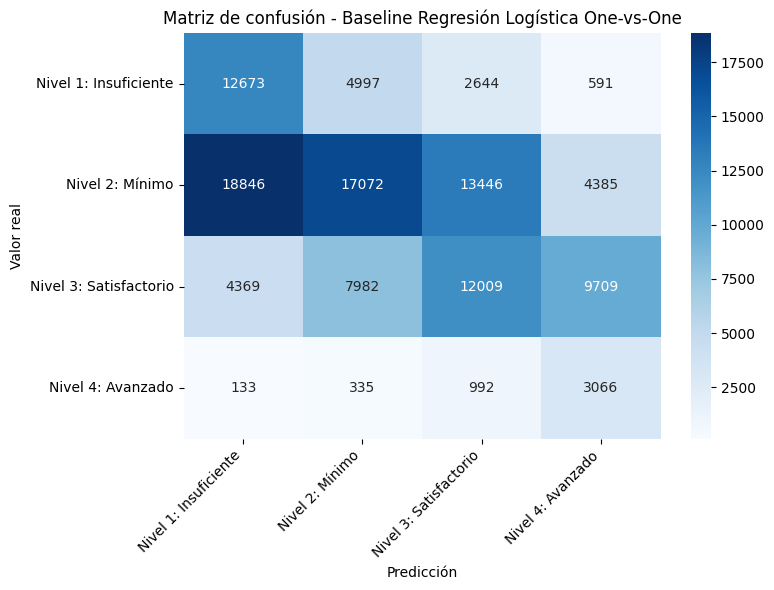

In [17]:
# ============================================================
# 13.1 Matriz de confusión baseline
# ============================================================

clases = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_pred_baseline,
    labels=clases
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)

plt.title("Matriz de confusión - Baseline Regresión Logística One-vs-One")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. Verificación explícita del preprocesamiento en entrenamiento y prueba

Aunque el `Pipeline` aplica automáticamente el preprocesamiento cuando se llama `predict(X_test)`, en esta celda se verifica de forma explícita que:

1. El pipeline fue ajustado únicamente con `X_train`.
2. Las transformaciones aprendidas en entrenamiento se aplican después sobre `X_test`.
3. No se recalculan imputaciones, codificadores ni escaladores usando el conjunto de prueba.

Esta verificación es importante para evitar fuga de información.


In [19]:
# ============================================================
# 15. Verificación explícita del preprocesamiento en train y test
# ============================================================

# El pipeline completo tiene esta estructura:
# 1. feature_engineering
# 2. agrupacion_categorias
# 3. preprocessor
# 4. classifier
#
# Para inspeccionar el preprocesamiento, tomamos todas las etapas
# excepto el clasificador final.
pipeline_preprocesamiento_final = Pipeline(
    steps=modelo_final.steps[:-1]
)

# IMPORTANTE:
# Esta transformación NO ajusta nada nuevo.
# Usa los parámetros aprendidos durante fit(X_train, y_train):
# - moda para imputación,
# - categorías del OneHotEncoder,
# - mapeo del OrdinalEncoder,
# - parámetros del StandardScaler.
X_train_preprocesado = pipeline_preprocesamiento_final.transform(X_train)
X_test_preprocesado = pipeline_preprocesamiento_final.transform(X_test)

print("Verificación de preprocesamiento")
print("-" * 60)
print("X_train original:", X_train.shape)
print("X_train preprocesado:", X_train_preprocesado.shape)
print("X_test original:", X_test.shape)
print("X_test preprocesado:", X_test_preprocesado.shape)

assert X_train_preprocesado.shape[0] == X_train.shape[0], (
    "Error: el número de filas preprocesadas de train no coincide."
)

assert X_test_preprocesado.shape[0] == X_test.shape[0], (
    "Error: el número de filas preprocesadas de test no coincide."
)

assert X_train_preprocesado.shape[1] == X_test_preprocesado.shape[1], (
    "Error: train y test no tienen el mismo número de columnas después del preprocesamiento."
)

print("\nValidación correcta:")
print("El conjunto de test fue transformado con el mismo pipeline ajustado en entrenamiento.")
print("No se realizó fit ni imputación independiente sobre X_test.")


Verificación de preprocesamiento
------------------------------------------------------------
X_train original: (452992, 16)
X_train preprocesado: (452992, 38)
X_test original: (113249, 16)
X_test preprocesado: (113249, 38)

Validación correcta:
El conjunto de test fue transformado con el mismo pipeline ajustado en entrenamiento.
No se realizó fit ni imputación independiente sobre X_test.


## 16. Métricas finales en test antes de guardar el modelo

En esta sección se calculan las métricas finales sobre `X_test`.

La instrucción:

```python
modelo_final.predict(X_test)
```

aplica internamente todo el preprocesamiento al conjunto de prueba, usando exclusivamente los parámetros aprendidos desde `X_train`.


In [20]:
# ============================================================
# 16. Evaluación final en test antes de guardar el modelo
# ============================================================

# Al llamar predict sobre X_test, el Pipeline ejecuta automáticamente:
# feature_engineering -> agrupacion_categorias -> preprocessor -> classifier.
# Por tanto, X_test sí pasa por el mismo preprocesamiento entrenado con X_train.
y_pred_final = modelo_final.predict(X_test)

accuracy_final = accuracy_score(y_test, y_pred_final)
f1_macro_final = f1_score(y_test, y_pred_final, average="macro")
f1_weighted_final = f1_score(y_test, y_pred_final, average="weighted")

metricas_finales_test = pd.DataFrame({
    "modelo": ["Regresión Logística One-vs-One"],
    "dataset_evaluacion": ["test"],
    "accuracy": [accuracy_final],
    "f1_macro": [f1_macro_final],
    "f1_weighted": [f1_weighted_final],
    "n_train": [len(X_train)],
    "n_test": [len(X_test)]
})

# Se conserva también el nombre usado en el artefacto de guardado.
metricas_finales = metricas_finales_test.copy()

print("Métricas finales en TEST antes de guardar el modelo")
print("-" * 60)
display(metricas_finales_test)

print("\nReporte de clasificación en TEST:")
print(classification_report(y_test, y_pred_final, zero_division=0))


Métricas finales en TEST antes de guardar el modelo
------------------------------------------------------------


,modelo,dataset_evaluacion,accuracy,f1_macro,f1_weighted,n_train,n_test
0,Regresión Logística One-vs-One,test,0.395765,0.376651,0.400196,452992,113249



Reporte de clasificación en TEST:
                        precision    recall  f1-score   support

 Nivel 1: Insuficiente       0.35      0.61      0.45     20905
       Nivel 2: Mínimo       0.56      0.32      0.41     53749
Nivel 3: Satisfactorio       0.41      0.35      0.38     34069
     Nivel 4: Avanzado       0.17      0.68      0.28      4526

              accuracy                           0.40    113249
             macro avg       0.37      0.49      0.38    113249
          weighted avg       0.46      0.40      0.40    113249



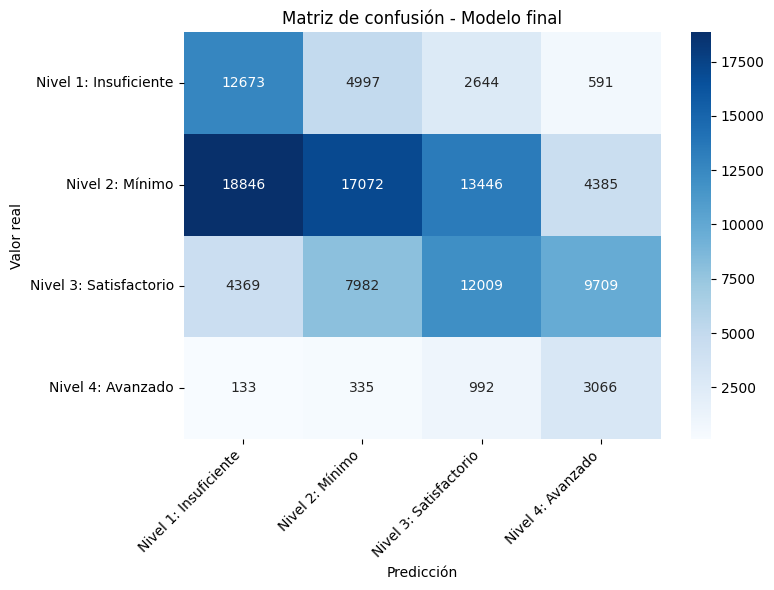

In [21]:
# ============================================================
# 16.1 Matriz de confusión final en test
# ============================================================

clases = sorted(pd.Series(y_test).unique())

cm_final = confusion_matrix(
    y_test,
    y_pred_final,
    labels=clases
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=clases,
    yticklabels=clases
)

plt.title("Matriz de confusión - Modelo final")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 17. Inspección de variables generadas por el preprocesamiento

Esta celda permite revisar cuántas variables quedan después de aplicar Ordinal Encoding, One Hot Encoding y escalamiento.

In [22]:
# ============================================================
# 17. Inspección de variables transformadas
# ============================================================

try:
    feature_names = modelo_final.named_steps["preprocessor"].get_feature_names_out()
    print("Cantidad de variables después del preprocesamiento:", len(feature_names))
    display(pd.DataFrame({"feature": feature_names}).head(50))
except Exception as e:
    print("No fue posible extraer los nombres de variables transformadas.")
    print("Detalle:", e)

Cantidad de variables después del preprocesamiento: 38


,feature
0,ordinal__fami_estratovivienda
1,ordinal__fami_educacionmadre
2,ordinal__fami_educacionpadre
3,ordinal__fami_cuartoshogar
4,ordinal__fami_personashogar
5,nominal__cole_bilingue_N
6,nominal__cole_bilingue_S
7,nominal__cole_calendario_A
8,nominal__cole_calendario_B
9,nominal__cole_calendario_OTRO


## 18. Guardar el modelo final

Después de calcular y revisar las métricas finales en test, se guarda el pipeline completo, incluyendo feature engineering, agrupación de categorías, imputación, codificación, escalamiento y modelo.

In [24]:
# ============================================================
# 18. Guardar modelo final
# ============================================================

if "metricas_finales_test" not in globals():
    raise RuntimeError(
        "Antes de guardar el modelo debes ejecutar la celda de métricas finales en test."
    )

MODEL_PATH = os.path.join(BASE_DIR, "modelo_logistica_ovo_pipeline.joblib")

artefacto_modelo = {
    "modelo": modelo_final,
    "target_col": TARGET_COL,
    "columnas_entrenamiento": X_train.columns.tolist(),
    "metricas_test": metricas_finales_test,
    "metricas": metricas_finales_test,
    "ordinal_cols": ordinal_cols,
    "nominal_cols": nominal_cols,
    "columnas_eliminadas": columnas_existentes_a_eliminar,
    "id_cols_no_modelar": id_cols_no_modelar,
    "shape_X_train_original": X_train.shape,
    "shape_X_test_original": X_test.shape,
    "shape_X_train_preprocesado": X_train_preprocesado.shape,
    "shape_X_test_preprocesado": X_test_preprocesado.shape
}

joblib.dump(artefacto_modelo, MODEL_PATH)

print("Modelo guardado después de evaluar métricas en test.")
print(f"Modelo guardado en: {MODEL_PATH}")
display(metricas_finales_test)


Modelo guardado después de evaluar métricas en test.
Modelo guardado en: /content/drive/MyDrive/Aprendizaje de Maquina Aplicado/TrabajoFinal/Data/Output/modelo_logistica_ovo_pipeline.joblib


,modelo,dataset_evaluacion,accuracy,f1_macro,f1_weighted,n_train,n_test
0,Regresión Logística One-vs-One,test,0.395765,0.376651,0.400196,452992,113249


## 19. Ejemplo de inferencia con nuevos datos

Para clasificar nuevos registros, se debe entregar un DataFrame con la misma estructura de columnas predictoras originales. El pipeline se encarga de aplicar las transformaciones necesarias.

In [25]:
# ============================================================
# 19. Ejemplo de inferencia
# ============================================================

n_ejemplo = min(5, len(X_test))

nuevos_datos = X_test.head(n_ejemplo).copy()

predicciones = modelo_final.predict(nuevos_datos)

resultado_inferencia = nuevos_datos.copy()
resultado_inferencia["prediccion"] = predicciones

display(resultado_inferencia)

,estu_tipodocumento,cole_bilingue,cole_calendario,cole_caracter,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_genero,fami_cuartoshogar,fami_educacionmadre,fami_educacionpadre,fami_estratovivienda,fami_personashogar,fami_tienecomputador,fami_tieneinternet,prediccion
455741,TI,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,CALI,OFICIAL,F,Cinco,Educación profesional incompleta,No sabe,Estrato 2,5 a 6,Si,Si,Nivel 2: Mínimo
535232,CC,N,A,ACADÉMICO,MIXTO,SABATINA,MEDELLÍN,NO OFICIAL,F,Dos,Primaria incompleta,Primaria incompleta,Estrato 2,5 a 6,No,No,Nivel 1: Insuficiente
55133,TI,NaN,A,ACADÉMICO,MIXTO,COMPLETA,SOACHA,NO OFICIAL,M,Tres,No sabe,No sabe,Estrato 3,3 a 4,Si,Si,Nivel 3: Satisfactorio
11946,TI,NaN,B,ACADÉMICO,MIXTO,MAÑANA,CALI,NO OFICIAL,M,Tres,Técnica o tecnológica incompleta,Educación profesional completa,Estrato 4,3 a 4,Si,Si,Nivel 4: Avanzado
414565,TI,N,A,TÉCNICO/ACADÉMICO,MIXTO,UNICA,BARRANCABERMEJA,OFICIAL,M,Uno,No sabe,No sabe,Estrato 2,1 a 2,No,Si,Nivel 2: Mínimo


## 20. Conclusión metodológica

El flujo construido sigue buenas prácticas de modelado supervisado:

- Elimina columnas no relevantes o previamente identificadas para depuración.
- Controla duplicados por identificador del estudiante.
- Excluye identificadores del entrenamiento para evitar sobreajuste o fuga de información.
- Separa entrenamiento y prueba antes de aprender imputaciones, codificaciones o escalamiento.
- Integra imputación, agrupación de categorías, encoding y modelo dentro de un único `Pipeline`.
- Verifica explícitamente que `X_test` es transformado con el preprocesamiento aprendido desde `X_train`.
- Evalúa el desempeño en test, antes de guardar el modelo, con `accuracy`, `F1 macro`, `F1 weighted` y matriz de confusión.
- Permite optimización opcional de hiperparámetros usando validación cruzada.